# 1. Problem Statement
Objective: Build a multiclass text classification model that predicts the property category from a given property address.

The dataset contains 10,032 property addresses belonging to five categories:

flat
houseorplot
landparcel
commercial unit
others

The raw address data contains substantial text noise, including Unicode homoglyphs, invisible characters, full-width digits, inconsistent casing, and formatting variations. Therefore, the project focuses on building a robust preprocessing and machine learning pipeline that can handle noisy address text and accurately classify the property category.

The final system should:

Audit and clean the raw address text.
Detect and address Unicode-related irregularities.
Analyze duplicates and potential data leakage.
Split the data into training and validation sets without allowing duplicate address groups to cross partitions.
Convert addresses into numerical text features using TF-IDF.
Compare word-level, character-level, and combined representations.
Tune the Linear SVM hyperparameters.
Analyze validation errors.
Train the selected final model on the complete labeled dataset.
Later evaluate the model on a separate test dataset.

#2. Import Libraries

In [40]:
import pandas as pd
import numpy as np
import re
import unicodedata

#3. Load Dataset

In [41]:
df = pd.read_excel('train_dataset.xlsx')

df.head()

,property_address,categories
0,"Flat-702,Floоr-7 Sidd​hіvinayak Annех S Νo Оld- １２9/3 , New -８８/3Villаge Dokalі, Balk‍umThane(W) Тhаne ４０0６01 Маharasht rа",flat
1,"flаt-11０３,flоor-１1 ѕ aroj сhаn​drа krupa s no 2５7/１/４, 2b‍, 2c old sno６６8‌,vill. bhaya​n dаr tal & distthane a‍mr utwani tеmbаroadbhayand erw estmira​-bhayandar 401１0‌1 maharаshtra",flat
2,"Survеy No. 31‍32/9, W‌ard Νo. Кothlapur, Near Railway Stаtion,Hуdеrаb‍ad, Tеlangana - ７９010６",landparcel
3,"314‍, 7 32,Аurora​, Hiranаndani Fоrtune Ci‌ty Panvel Nh‌4Survеy Νо 11‍7 Вhokаrpadа V‌lge R aigha‍d, Nh​4 Survey Νo 385Bhoкarрad​a Vl‍ge Rаi‌ghad Maharaѕhtrа ４ 10206 , N‌h4 Ѕu rvey Νo 7３7, H‍irаnan...",flat
4,"Gа‌t Number ４, Malmatta Number ９0, А/Р R​ohкаl TаlРara‌nda Dі ѕtrict Dha​rashiv",houseorplot


# 4. Dataset Overview

In [42]:
df.shape

(10032, 2)

In [43]:
df.columns

Index(['property_address', 'categories'], dtype='object')

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10032 entries, 0 to 10031
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   property_address  10032 non-null  object
 1   categories        10032 non-null  object
dtypes: object(2)
memory usage: 156.9+ KB


In [45]:
df.isnull().sum()

,0
property_address,0
categories,0


#5. Class Distribution

In [46]:
df["categories"].value_counts()

,count
categories,
flat,3464
houseorplot,3047
others,1297
commercial unit,1156
landparcel,1068


6. Raw Text Quality Audit

In [47]:
pd.set_option("display.max_colwidth", 200)

df[["property_address", "categories"]].head(20)

,property_address,categories
0,"Flat-702,Floоr-7 Sidd​hіvinayak Annех S Νo Оld- １２9/3 , New -８８/3Villаge Dokalі, Balk‍umThane(W) Тhаne ４０0６01 Маharasht rа",flat
1,"flаt-11０３,flоor-１1 ѕ aroj сhаn​drа krupa s no 2５7/１/４, 2b‍, 2c old sno６６8‌,vill. bhaya​n dаr tal & distthane a‍mr utwani tеmbаroadbhayand erw estmira​-bhayandar 401１0‌1 maharаshtra",flat
2,"Survеy No. 31‍32/9, W‌ard Νo. Кothlapur, Near Railway Stаtion,Hуdеrаb‍ad, Tеlangana - ７９010６",landparcel
3,"314‍, 7 32,Аurora​, Hiranаndani Fоrtune Ci‌ty Panvel Nh‌4Survеy Νо 11‍7 Вhokаrpadа V‌lge R aigha‍d, Nh​4 Survey Νo 385Bhoкarрad​a Vl‍ge Rаi‌ghad Maharaѕhtrа ４ 10206 , N‌h4 Ѕu rvey Νo 7３7, H‍irаnan...",flat
4,"Gа‌t Number ４, Malmatta Number ９0, А/Р R​ohкаl TаlРara‌nda Dі ѕtrict Dha​rashiv",houseorplot
5,"kаmalрur, m‍irрur mееrpur bulandsh‌a hr",others
6,"Flаt-707‍,Floоr-7 Shri Lа​xmі Cеleb‍ration Rеsidency Рlоt Inѕ-6,Sеctor 2Bvaѕundhаra Ghаz іaba‍d ２０1012 U t‌tаr Pradesh",flat
7,"Flat-9０4,Fl​oor-9 The Оrchаrd Residenсy Ph​-Ιi Tower-１ Ѕ Νо 1４6В, Cts-16６, 1６6/‌1 Тo23,L.В.‍S Marg GhatкоparWеst M​umbaі 400０​86 Mahаr​ashtra",flat
8,Open P‌lot No 972 NaΝa MainRoad,others
9,Νa Νa N‌ana NaGaneshрur Roоrkee Hаridwar Roorkee Uttar‌akhand ２47６67,others


#6.1 Check for unusual Unicode / invisible character Detection


In [48]:
import unicodedata

def find_unusual_characters(text):
    unusual = []

    for ch in str(text):
        category = unicodedata.category(ch)

        if ord(ch) > 127 or category in {"Cc", "Cf"}:
            unusual.append({
                "character": repr(ch),
                "unicode": f"U+{ord(ch):04X}",
                "name": unicodedata.name(ch, "UNKNOWN"),
                "category": category
            })

    return unusual

In [49]:
unusual_rows = []

for idx, text in df["property_address"].items():
    chars = find_unusual_characters(text)

    if chars:
        unusual_rows.append({
            "index": idx,
            "address": text,
            "unusual_characters": chars
        })

len(unusual_rows)

10028

In [50]:
unusual_rows[:5]

[{'index': 0,
  'address': 'Flat-702,Floоr-7 Sidd\u200bhіvinayak Annех S Νo Оld- １２9/3 , New -８８/3Villаge Dokalі, Balk\u200dumThane(W) Тhаne ４０0６01 Маharasht rа',
  'unusual_characters': [{'character': "'о'",
    'unicode': 'U+043E',
    'name': 'CYRILLIC SMALL LETTER O',
    'category': 'Ll'},
   {'character': "'\\u200b'",
    'unicode': 'U+200B',
    'name': 'ZERO WIDTH SPACE',
    'category': 'Cf'},
   {'character': "'і'",
    'unicode': 'U+0456',
    'name': 'CYRILLIC SMALL LETTER BYELORUSSIAN-UKRAINIAN I',
    'category': 'Ll'},
   {'character': "'е'",
    'unicode': 'U+0435',
    'name': 'CYRILLIC SMALL LETTER IE',
    'category': 'Ll'},
   {'character': "'х'",
    'unicode': 'U+0445',
    'name': 'CYRILLIC SMALL LETTER HA',
    'category': 'Ll'},
   {'character': "'Ν'",
    'unicode': 'U+039D',
    'name': 'GREEK CAPITAL LETTER NU',
    'category': 'Lu'},
   {'character': "'О'",
    'unicode': 'U+041E',
    'name': 'CYRILLIC CAPITAL LETTER O',
    'category': 'Lu'},
   {'charact

# 6.2 Unicode Character Frequency Analysis



In [51]:
from collections import Counter

char_counts = Counter()

for text in df["property_address"]:
    for ch in str(text):
        if ord(ch) > 127 or unicodedata.category(ch) in {"Cc", "Cf"}:
            char_counts[ch] += 1

for ch, count in char_counts.most_common(30):
    print(
        repr(ch),
        f"U+{ord(ch):04X}",
        unicodedata.name(ch, "UNKNOWN"),
        count
    )

'а' U+0430 CYRILLIC SMALL LETTER A 34978
'\u200c' U+200C ZERO WIDTH NON-JOINER 18223
'\u200b' U+200B ZERO WIDTH SPACE 18015
'\u200d' U+200D ZERO WIDTH JOINER 18008
'о' U+043E CYRILLIC SMALL LETTER O 15196
'і' U+0456 CYRILLIC SMALL LETTER BYELORUSSIAN-UKRAINIAN I 13605
'е' U+0435 CYRILLIC SMALL LETTER IE 12851
'１' U+FF11 FULLWIDTH DIGIT ONE 8877
'ѕ' U+0455 CYRILLIC SMALL LETTER DZE 7917
'０' U+FF10 FULLWIDTH DIGIT ZERO 7195
'２' U+FF12 FULLWIDTH DIGIT TWO 6208
'Ν' U+039D GREEK CAPITAL LETTER NU 5660
'３' U+FF13 FULLWIDTH DIGIT THREE 4874
'４' U+FF14 FULLWIDTH DIGIT FOUR 4759
'р' U+0440 CYRILLIC SMALL LETTER ER 4413
'Ѕ' U+0405 CYRILLIC CAPITAL LETTER DZE 4131
'５' U+FF15 FULLWIDTH DIGIT FIVE 4126
'Р' U+0420 CYRILLIC CAPITAL LETTER ER 3470
'６' U+FF16 FULLWIDTH DIGIT SIX 3388
'с' U+0441 CYRILLIC SMALL LETTER ES 3073
'７' U+FF17 FULLWIDTH DIGIT SEVEN 3072
'к' U+043A CYRILLIC SMALL LETTER KA 3025
'８' U+FF18 FULLWIDTH DIGIT EIGHT 2968
'\n' U+000A UNKNOWN 2907
'А' U+0410 CYRILLIC CAPITAL LETTER A 28

# 6.3 NFKC Normalization Experiment

In [52]:
test = df["property_address"].iloc[0]

print("ORIGINAL:")
print(test)

print("\nNFKC:")
print(unicodedata.normalize("NFKC", test))

ORIGINAL:
Flat-702,Floоr-7 Sidd​hіvinayak Annех S Νo Оld- １２9/3 , New -８８/3Villаge Dokalі, Balk‍umThane(W) Тhаne ４０0６01 Маharasht rа

NFKC:
Flat-702,Floоr-7 Sidd​hіvinayak Annех S Νo Оld- 129/3 , New -88/3Villаge Dokalі, Balk‍umThane(W) Тhаne 400601 Маharasht rа


# Raw Text Quality Audit
The raw address data was inspected for Unicode irregularities before feature extraction. A total of 10,028 out of 10,032 addresses (99.96%) contained at least one non-ASCII or Unicode control/format character. The observed irregularities included invisible Unicode characters, full-width digits, and visually confusable Cyrillic and Greek characters. NFKC normalization successfully converts full-width characters such as digits to their standard forms, but does not resolve visually confusable characters such as Cyrillic "а" and "о". Therefore, additional targeted normalization is required before feature extraction.


# 7. **Text Preprocessing**
# 7.1 Unicode Normalization

In [53]:
def normalize_address_basic(text):
    if pd.isna(text):
        return ""

    text = str(text)

    # Unicode normalization
    text = unicodedata.normalize("NFKC", text)

    # Remove invisible Unicode format characters
    text = "".join(
        ch for ch in text
        if unicodedata.category(ch) not in {"Cf"}
    )

    # Convert to lowercase
    text = text.lower()

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [54]:
df["address_basic"] = df["property_address"].apply(
    normalize_address_basic
)

In [55]:
for i in range(5):
    print("ORIGINAL :", df.loc[i, "property_address"])
    print("CLEANED  :", df.loc[i, "address_basic"])
    print("-" * 100)

ORIGINAL : Flat-702,Floоr-7 Sidd​hіvinayak Annех S Νo Оld- １２9/3 , New -８８/3Villаge Dokalі, Balk‍umThane(W) Тhаne ４０0６01 Маharasht rа
CLEANED  : flat-702,floоr-7 siddhіvinayak annех s νo оld- 129/3 , new -88/3villаge dokalі, balkumthane(w) тhаne 400601 маharasht rа
----------------------------------------------------------------------------------------------------
ORIGINAL : flаt-11０３,flоor-１1 ѕ aroj сhаn​drа krupa s no 2５7/１/４, 2b‍, 2c old sno６６8‌,vill. bhaya​n dаr tal & distthane a‍mr utwani tеmbаroadbhayand erw estmira​-bhayandar 401１0‌1 maharаshtra
CLEANED  : flаt-1103,flоor-11 ѕ aroj сhаndrа krupa s no 257/1/4, 2b, 2c old sno668,vill. bhayan dаr tal & distthane amr utwani tеmbаroadbhayand erw estmira-bhayandar 401101 maharаshtra
----------------------------------------------------------------------------------------------------
ORIGINAL : Survеy No. 31‍32/9, W‌ard Νo. Кothlapur, Near Railway Stаtion,Hуdеrаb‍ad, Tеlangana - ７９010６
CLEANED  : survеy no. 3132/9, ward νo. кothlapur, n

# 7.2 Homoglyph Correction

In [56]:
HOMOGLYPH_MAP = {
    # Cyrillic lowercase
    "а": "a",
    "е": "e",
    "і": "i",
    "о": "o",
    "р": "p",
    "с": "c",
    "к": "k",
    "у": "y",
    "х": "x",
    "в": "v",
    "м": "m",
    "т": "t",
    "ѕ": "s",

    # Cyrillic uppercase
    "А": "A",
    "Е": "E",
    "І": "I",
    "О": "O",
    "Р": "P",
    "С": "C",
    "К": "K",
    "У": "Y",
    "Х": "X",
    "В": "V",
    "М": "M",
    "Т": "T",
    "Ѕ": "S",

    # Greek
    "Ν": "N",
}

In [57]:
def normalize_address(text):
    if pd.isna(text):
        return ""

    text = str(text)

    # 1. Unicode compatibility normalization
    text = unicodedata.normalize("NFKC", text)

    # 2. Replace known homoglyphs
    text = "".join(HOMOGLYPH_MAP.get(ch, ch) for ch in text)

    # 3. Remove invisible Unicode format characters
    text = "".join(
        ch for ch in text
        if unicodedata.category(ch) != "Cf"
    )

    # 4. Lowercase
    text = text.lower()

    # 5. Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

# 7.3 Lowercase Conversion

In [58]:
df["clean_address"] = df["property_address"].apply(normalize_address)

In [59]:
for i in range(5):
    print("ORIGINAL:")
    print(df.loc[i, "property_address"])

    print("\nCLEANED:")
    print(df.loc[i, "clean_address"])

    print("\n" + "-" * 100)

ORIGINAL:
Flat-702,Floоr-7 Sidd​hіvinayak Annех S Νo Оld- １２9/3 , New -８８/3Villаge Dokalі, Balk‍umThane(W) Тhаne ４０0６01 Маharasht rа

CLEANED:
flat-702,floor-7 siddhivinayak annex s no old- 129/3 , new -88/3village dokali, balkumthane(w) thane 400601 maharasht ra

----------------------------------------------------------------------------------------------------
ORIGINAL:
flаt-11０３,flоor-１1 ѕ aroj сhаn​drа krupa s no 2５7/１/４, 2b‍, 2c old sno６６8‌,vill. bhaya​n dаr tal & distthane a‍mr utwani tеmbаroadbhayand erw estmira​-bhayandar 401１0‌1 maharаshtra

CLEANED:
flat-1103,floor-11 s aroj chandra krupa s no 257/1/4, 2b, 2c old sno668,vill. bhayan dar tal & distthane amr utwani tembaroadbhayand erw estmira-bhayandar 401101 maharashtra

----------------------------------------------------------------------------------------------------
ORIGINAL:
Survеy No. 31‍32/9, W‌ard Νo. Кothlapur, Near Railway Stаtion,Hуdеrаb‍ad, Tеlangana - ７９010６

CLEANED:
survey no. 3132/9, ward no. kothlapur, near 

# Validating Preprocessing

In [60]:
remaining_unusual = []

for idx, text in df["clean_address"].items():
    chars = []

    for ch in text:
        if ord(ch) > 127 or unicodedata.category(ch) in {"Cc", "Cf"}:
            chars.append(ch)

    if chars:
        remaining_unusual.append((idx, chars))

len(remaining_unusual)

2015

In [61]:
remaining_unusual[:10]

[(7, ['ι']),
 (11, ['ι']),
 (18, ['ј']),
 (25, ['н']),
 (30, ['ι', 'ј']),
 (32, ['н']),
 (36, ['н']),
 (46, ['н']),
 (53, ['н']),
 (54, ['“', '”', '“', 'н', 'н', '”', 'н'])]

In [62]:
remaining_counts = Counter()

for text in df["clean_address"]:
    for ch in str(text):
        if ord(ch) > 127 or unicodedata.category(ch) in {"Cc", "Cf"}:
            remaining_counts[ch] += 1

for ch, count in remaining_counts.most_common():
    print(
        repr(ch),
        f"U+{ord(ch):04X}",
        unicodedata.name(ch, "UNKNOWN"),
        count
    )

'н' U+043D CYRILLIC SMALL LETTER EN 1185
'ι' U+03B9 GREEK SMALL LETTER IOTA 703
'ј' U+0458 CYRILLIC SMALL LETTER JE 478
'�' U+FFFD REPLACEMENT CHARACTER 399
'–' U+2013 EN DASH 95
'“' U+201C LEFT DOUBLE QUOTATION MARK 77
'”' U+201D RIGHT DOUBLE QUOTATION MARK 75
'ζ' U+03B6 GREEK SMALL LETTER ZETA 38
'‘' U+2018 LEFT SINGLE QUOTATION MARK 14
'’' U+2019 RIGHT SINGLE QUOTATION MARK 11


# Inspecting character, especially н, ι, ј, �, and ζ

In [63]:
chars_to_check = ["н", "ι", "ј", "�", "ζ", "–", "“", "”", "‘", "’"]

for target in chars_to_check:
    print("\n" + "=" * 80)
    print("CHARACTER:", repr(target))

    examples = df[
        df["clean_address"].str.contains(target, regex=False, na=False)
    ]["clean_address"].head(5)

    for example in examples:
        print(example)


CHARACTER: 'н'
unit-m-82-4,floor-04 m3m soulitude phase 2 sno rect no- 60//killa no-1/12/1,sector 89,village нayatpur gurgaon 122001 haryana
nanaplotno -1346 p , sector 4ext.rohtak, plot no - 1346 p , sector 4 ext. rohta k, plot no - 13 46 p , sector4 ext. rohta k, rohtak, plot no - 1346p , sector 4 ext.roht ak, roh tak,нaryana, 124001
ne am chouk,нouseno 180, dr on patta no 52, wa rd no 20,patwari halka no 26, gram kaneri,near by neam chouk,ratlam,madhya pradesh,457001
flat-l416,floor-4 casagrand нola-block-11 s no various,sholinganallurvilla ge, erikarisalaisholinganallur taluk, chennaidistrict chennai 600119 tamil nadu
row нo use,124,tirupati dham,ujjain,ujjain,ujj ain,madhya pradesh,456006

CHARACTER: 'ι'
flat-904,floor-9 the orchard residency ph-ιi tower-1 s no 146v, cts-166, 166/1 to23,l.v.s marg ghatkoparwest mumbai 400086 maharashtra
flat,2004,2oth , my home bhooja flat no2004 20th floor b lack no .i tower .vi vasement-ιii,biodiversitypark, anandbagh malkajgiri,n.a,hyderabad,s

# Updating Mapping

In [64]:
HOMOGLYPH_MAP.update({
    "н": "n",
    "ι": "i",
    "ј": "j",
    "ζ": "z",
})

PUNCTUATION_MAP = {
    "–": "-",
    "“": '"',
    "”": '"',
    "‘": "'",
    "’": "'",
}

In [65]:
def normalize_address(text):
    if pd.isna(text):
        return ""

    text = str(text)

    # 1. Unicode compatibility normalization
    text = unicodedata.normalize("NFKC", text)

    # 2. Replace known homoglyphs
    text = "".join(HOMOGLYPH_MAP.get(ch, ch) for ch in text)

    # 3. Normalize punctuation
    text = "".join(PUNCTUATION_MAP.get(ch, ch) for ch in text)

    # 4. Remove invisible Unicode format characters
    text = "".join(
        ch for ch in text
        if unicodedata.category(ch) != "Cf"
    )

    # 5. Lowercase
    text = text.lower()

    # 6. Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [66]:
df["clean_address"] = df["property_address"].apply(normalize_address)

In [67]:
remaining_counts = Counter()

for text in df["clean_address"]:
    for ch in str(text):
        if ord(ch) > 127 or unicodedata.category(ch) in {"Cc", "Cf"}:
            remaining_counts[ch] += 1

for ch, count in remaining_counts.most_common():
    print(
        repr(ch),
        f"U+{ord(ch):04X}",
        unicodedata.name(ch, "UNKNOWN"),
        count
    )

'н' U+043D CYRILLIC SMALL LETTER EN 1185
'ι' U+03B9 GREEK SMALL LETTER IOTA 703
'ј' U+0458 CYRILLIC SMALL LETTER JE 478
'�' U+FFFD REPLACEMENT CHARACTER 399
'ζ' U+03B6 GREEK SMALL LETTER ZETA 38


# Preprocessing Summarization
I first audited the raw address text instead of assuming ASCII-clean input. The audit revealed widespread Unicode corruption, including zero-width characters, full-width digits, and visually confusable Cyrillic and Greek characters. I applied NFKC normalization for compatibility characters, followed by targeted homoglyph correction based on observed corruption patterns. Invisible Unicode format characters were removed, text was lowercased, and whitespace was normalized. I validated the transformation by re-running the Unicode audit and manually inspecting representative remaining characters. Replacement characters (U+FFFD) were retained rather than mapped heuristically because their original values could not be reliably recovered.

# Duplicate / Data Leakage Analysis

1.1Exact duplicate addresses

In [68]:
# Number of exact duplicate cleaned addresses
duplicate_count = df["clean_address"].duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 21


In [69]:
# Show some duplicate addresses
duplicates = df[df["clean_address"].duplicated(keep=False)].sort_values("clean_address")

duplicates[["property_address","clean_address", "categories"]]

,property_address,clean_address,categories
6395,"115/12-2-５,1１5/12-４\n thаlayazam\n vaikom","115/12-2-5,115/12-4 thalayazam vaikom",others
9038,"１15/１２-2-５,１15/１２-4\nThаlа​yazаm\n Vaikom","115/12-2-5,115/12-4 thalayazam vaikom",others
4379,"1１５/12-2-5,1１５/1２-4\n Thalaуazam\n Vаiкom","115/12-2-5,115/12-4 thalayazam vaikom",others
1281,243​Νawada Νawаda Naw​аda Nаwadа Bih‍ar 8051１0,243nawada nawada nawada nawada bihar 805110,houseorplot
2008,2４３nawа‌da nawada nawada nawada bihar 80511０,243nawada nawada nawada nawada bihar 805110,others
7746,452/453Asa​ngі A‍ditуaрur Saraіkela Kharѕawan Jamshedpur J‍hаrkhand 83２108,452/453asangi adityapur saraikela kharsawan jamshedpur jharkhand 832108,landparcel
1600,４５2/453asаngi adіtyapur ѕaraikela kharsаwan jamѕhedрur jharkhand 8３2108,452/453asangi adityapur saraikela kharsawan jamshedpur jharkhand 832108,houseorplot
8566,4Th Floo​r Dеluх C​еntеr １57C Lеnin Ѕaranі Kоlka‍ta,4th floor delux center 157c lenin sarani kolkata,others
9738,4th floor delux center 157c lenin sarani кolkata,4th floor delux center 157c lenin sarani kolkata,flat
7299,bhoѕari pun​e,bhosari pune,others


1.2 Checking Conflicting labels

In [70]:
label_counts_per_address = (
    df.groupby("clean_address")["categories"]
      .nunique()
)

conflicting_addresses = label_counts_per_address[
    label_counts_per_address > 1
]

print("Addresses with conflicting labels:",
      len(conflicting_addresses))

Addresses with conflicting labels: 5


In [71]:
conflicting_examples = df[
    df["clean_address"].isin(conflicting_addresses.index)
].sort_values("clean_address")

conflicting_examples[
    ["property_address", "clean_address", "categories"]
]

,property_address,clean_address,categories
1281,243​Νawada Νawаda Naw​аda Nаwadа Bih‍ar 8051１0,243nawada nawada nawada nawada bihar 805110,houseorplot
2008,2４３nawа‌da nawada nawada nawada bihar 80511０,243nawada nawada nawada nawada bihar 805110,others
1600,４５2/453asаngi adіtyapur ѕaraikela kharsаwan jamѕhedрur jharkhand 8３2108,452/453asangi adityapur saraikela kharsawan jamshedpur jharkhand 832108,houseorplot
7746,452/453Asa​ngі A‍ditуaрur Saraіkela Kharѕawan Jamshedpur J‍hаrkhand 83２108,452/453asangi adityapur saraikela kharsawan jamshedpur jharkhand 832108,landparcel
8566,4Th Floo​r Dеluх C​еntеr １57C Lеnin Ѕaranі Kоlka‍ta,4th floor delux center 157c lenin sarani kolkata,others
9738,4th floor delux center 157c lenin sarani кolkata,4th floor delux center 157c lenin sarani kolkata,flat
1244,nо ３‍51 іncl estаtе udumalpuram nandyаl,no 351 incl estate udumalpuram nandyal,commercial unit
4965,Νo 35‍１ Inс‍l Estate Udumalpurаm Nandуal,no 351 incl estate udumalpuram nandyal,houseorplot
6434,"Sy Nо 38‌, Sullya, Sull‍ia, Dakѕhina Kаnnada‌, Karnataкa,\n India, \n 574２3９","sy no 38, sullya, sullia, dakshina kannada, karnataka, india, 574239",houseorplot
7337,"sy no ３8, sullуa, sulliа, daкshіna кannаdа, karnataka,\n indiа, \n ５７4239","sy no 38, sullya, sullia, dakshina kannada, karnataka, india, 574239",landparcel


# Conclusion
Exact duplicate analysis identified 21 duplicate rows. Most duplicates represented the same address with different Unicode/formatting noise and had consistent labels. Five unique cleaned addresses had conflicting labels. These conflicting groups were retained rather than arbitrarily relabeled, and duplicate addresses will be kept within the same train/validation partition to prevent leakage.

# Creating Groups

In [72]:
df["group"] = df["clean_address"].factorize()[0]

print("Total rows:", len(df))
print("Unique address groups:", df["group"].nunique())

Total rows: 10032
Unique address groups: 10011


In [73]:
group_sizes = df.groupby("group").size()

print("Groups containing duplicates:", (group_sizes > 1).sum())
print("Largest group size:", group_sizes.max())

Groups containing duplicates: 20
Largest group size: 3


# Train/Validation Split

In [74]:
import sklearn

print(sklearn.__version__)

1.6.1


In [75]:
from sklearn.model_selection import StratifiedGroupKFold

X = df["clean_address"]
y = df["categories"]
groups = df["group"]

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, val_idx = next(
    sgkf.split(X, y, groups)
)

X_train = X.iloc[train_idx]
X_val = X.iloc[val_idx]

y_train = y.iloc[train_idx]
y_val = y.iloc[val_idx]

In [76]:
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 8028
Validation samples: 2004


Verfiying Class Distribution

In [77]:
print("Training distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nValidation distribution:")
print(y_val.value_counts(normalize=True).sort_index())

Training distribution:
categories
commercial unit    0.114973
flat               0.347658
houseorplot        0.299078
landparcel         0.106751
others             0.131540
Name: proportion, dtype: float64

Validation distribution:
categories
commercial unit    0.116267
flat               0.335828
houseorplot        0.322355
landparcel         0.105289
others             0.120259
Name: proportion, dtype: float64


In [78]:
train_addresses = set(X_train)
val_addresses = set(X_val)

overlap = train_addresses.intersection(val_addresses)

print("Exact address overlap:", len(overlap))

Exact address overlap: 0


# Train / Validation Split

The dataset was split into training and validation sets using a stratified group-aware split. clean_address was used as the grouping key so that duplicate representations of the same address could not appear in both partitions. Stratification was used to maintain approximately similar class distributions between training and validation data. A fixed random seed was used to ensure reproducibility.

# Feature Engineering

In [79]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

Word-level TF-IDF

In [82]:
word_vectorizer = TfidfVectorizer(
    analyzer="word", #here we are extracting words
    ngram_range=(1, 2), # This can capture useful combinations.
    min_df=2, #Ignore terms that occur only once in the training data.
    sublinear_tf=True #Uses a logarithmic term-frequency scaling, which can be useful for text data where some terms occur many times.
)

In [83]:
X_train_word = word_vectorizer.fit_transform(X_train)
X_val_word = word_vectorizer.transform(X_val)

In [87]:
word_vectorizer.fit_transform(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 209150 stored elements and shape (8028, 28841)>

In [88]:
word_vectorizer.transform(X_val)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 45152 stored elements and shape (2004, 28841)>

Check the Dimensions

In [86]:
print("Training shape:", X_train_word.shape)
print("Validation shape:", X_val_word.shape)

Training shape: (8028, 28841)
Validation shape: (2004, 28841)


Train Word TF-IDF Linear SVM

In [89]:
word_model = LinearSVC(
    C=1.0,
    class_weight="balanced"
)

word_model.fit(X_train_word, y_train)

LinearSVC(class_weight='balanced')

In [90]:
y_pred_word = word_model.predict(X_val_word)

In [104]:
accuracy = accuracy_score(y_val, y_pred_word)

macro_f1 = f1_score(
    y_val,
    y_pred_word,
    average="macro"
)

print("Word TF-IDF + Linear SVM")
print("Accuracy :", round(accuracy, 4))
print("Macro F1 :", round(macro_f1, 4))


print(classification_report(
    y_val,
    y_pred_word,
    digits=4
))



Word TF-IDF + Linear SVM
Accuracy : 0.8663
Macro F1 : 0.8479
                 precision    recall  f1-score   support

commercial unit     0.9220    0.8627    0.8914       233
           flat     0.9386    0.9079    0.9230       673
    houseorplot     0.8576    0.8669    0.8622       646
     landparcel     0.7883    0.8294    0.8083       211
         others     0.7269    0.7842    0.7545       241

       accuracy                         0.8663      2004
      macro avg     0.8467    0.8502    0.8479      2004
   weighted avg     0.8693    0.8663    0.8674      2004



Confusion Matrix

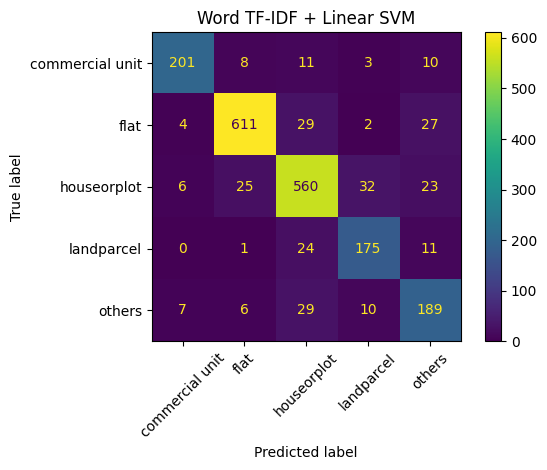

In [94]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=word_model.classes_
)

disp.plot(
    xticks_rotation=45
)

plt.title("Word TF-IDF + Linear SVM")
plt.tight_layout()
plt.show()

In [95]:
results = []

results.append({
    "Model": "Word TF-IDF + Linear SVM",
    "Accuracy": accuracy,
    "Macro F1": macro_f1
})

results

[{'Model': 'Word TF-IDF + Linear SVM',
  'Accuracy': 0.8662674650698603,
  'Macro F1': 0.8478640148598041}]

Charater TF-IDF

In [96]:
char_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=2,
    sublinear_tf=True
)

In [97]:
X_train_char = char_vectorizer.fit_transform(X_train)
X_val_char = char_vectorizer.transform(X_val)

In [98]:
print("Training shape:", X_train_char.shape)
print("Validation shape:", X_val_char.shape)

Training shape: (8028, 191680)
Validation shape: (2004, 191680)


Charater TF IDF + Linar SVM

In [99]:
char_model = LinearSVC(
    C=1.0,
    class_weight="balanced"
)

char_model.fit(X_train_char, y_train)

LinearSVC(class_weight='balanced')

In [100]:
y_pred_char = char_model.predict(X_val_char)

In [101]:
char_accuracy = accuracy_score(y_val, y_pred_char)

char_macro_f1 = f1_score(
    y_val,
    y_pred_char,
    average="macro"
)

print("Character TF-IDF + Linear SVM")
print("Accuracy :", round(char_accuracy, 4))
print("Macro F1 :", round(char_macro_f1, 4))

print(
    classification_report(
        y_val,
        y_pred_char,
        digits=4
    )
)

Character TF-IDF + Linear SVM
Accuracy : 0.8912
Macro F1 : 0.8761
                 precision    recall  f1-score   support

commercial unit     0.9123    0.8927    0.9024       233
           flat     0.9471    0.9316    0.9393       673
    houseorplot     0.8703    0.8932    0.8816       646
     landparcel     0.8507    0.8104    0.8301       211
         others     0.8120    0.8423    0.8269       241

       accuracy                         0.8912      2004
      macro avg     0.8785    0.8741    0.8761      2004
   weighted avg     0.8919    0.8912    0.8914      2004



Word + Charachter TF IDF

In [105]:
word_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_word = word_vectorizer.fit_transform(X_train)
X_val_word = word_vectorizer.transform(X_val)

In [106]:
char_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=2,
    sublinear_tf=True
)

X_train_char = char_vectorizer.fit_transform(X_train)
X_val_char = char_vectorizer.transform(X_val)

In [107]:
from scipy.sparse import hstack

In [108]:
X_train_combined = hstack([
    X_train_word,
    X_train_char
])

X_val_combined = hstack([
    X_val_word,
    X_val_char
])

In [109]:
print("Train shape:", X_train_combined.shape)
print("Validation shape:", X_val_combined.shape)

Train shape: (8028, 220521)
Validation shape: (2004, 220521)


In [110]:
combined_model = LinearSVC(
    C=1.0,
    class_weight="balanced"
)

combined_model.fit(
    X_train_combined,
    y_train
)

LinearSVC(class_weight='balanced')

In [111]:
y_pred_combined = combined_model.predict(
    X_val_combined
)

In [113]:
combined_accuracy = accuracy_score(
    y_val,
    y_pred_combined
)

combined_macro_f1 = f1_score(
    y_val,
    y_pred_combined,
    average="macro"
)

print("Accuracy :", round(combined_accuracy, 4))
print("Macro F1 :", round(combined_macro_f1, 4))

print(
    classification_report(
        y_val,
        y_pred_combined,
        digits=4
    )
)

Accuracy : 0.8922
Macro F1 : 0.8783
                 precision    recall  f1-score   support

commercial unit     0.9324    0.8884    0.9099       233
           flat     0.9511    0.9242    0.9375       673
    houseorplot     0.8700    0.9009    0.8852       646
     landparcel     0.8670    0.8341    0.8502       211
         others     0.7852    0.8340    0.8089       241

       accuracy                         0.8922      2004
      macro avg     0.8811    0.8763    0.8783      2004
   weighted avg     0.8940    0.8922    0.8927      2004



In [115]:
results = [
    {
        "Model": "Word TF-IDF + Linear SVM",
        "Accuracy": 0.8663,
        "Macro F1": 0.8479
    },
    {
        "Model": "Character TF-IDF + Linear SVM",
        "Accuracy": 0.8912,
        "Macro F1": 0.8761
    },
    {
        "Model": "Word + Character TF-IDF + Linear SVM",
        "Accuracy": combined_accuracy,
        "Macro F1": combined_macro_f1
    }
]

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Macro F1
0,Word TF-IDF + Linear SVM,0.866300,0.847900
1,Character TF-IDF + Linear SVM,0.891200,0.876100
2,Word + Character TF-IDF + Linear SVM,0.892216,0.878322


Observation:
Character-level TF-IDF substantially outperformed word-level TF-IDF, indicating that subword patterns are useful for noisy property addresses containing spelling variations, abbreviations, numbers, and inconsistent formatting. Combining word and character features produced a further improvement in Macro F1 from 0.8761 to 0.8783, so the combined representation was retained as the current best baseline.

# Linear SVM hyperparameter tuning on the Word + Character TF-IDF features.

Test different C values

In [116]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

C_values = [0.1, 0.5, 1.0, 2.0, 5.0]

svm_results = []

for c in C_values:
    model = LinearSVC(
        C=c,
        class_weight="balanced"
    )

    model.fit(X_train_combined, y_train)

    pred = model.predict(X_val_combined)

    accuracy = accuracy_score(y_val, pred)
    macro_f1 = f1_score(
        y_val,
        pred,
        average="macro"
    )

    svm_results.append({
        "C": c,
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    })

svm_results_df = pd.DataFrame(svm_results)

svm_results_df

,C,Accuracy,Macro F1
0,0.1,0.878244,0.863301
1,0.5,0.892216,0.878583
2,1.0,0.892216,0.878322
3,2.0,0.891218,0.877875
4,5.0,0.890719,0.875435


# Test whether class weighting actually helps

In [117]:
class_weight="balanced"

In [118]:
weight_values = [None, "balanced"]

weight_results = []

for weight in weight_values:

    model = LinearSVC(
        C=1.0,
        class_weight=weight
    )

    model.fit(
        X_train_combined,
        y_train
    )

    pred = model.predict(
        X_val_combined
    )

    accuracy = accuracy_score(
        y_val,
        pred
    )

    macro_f1 = f1_score(
        y_val,
        pred,
        average="macro"
    )

    weight_results.append({
        "Class Weight": weight,
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    })

pd.DataFrame(weight_results)

,Class Weight,Accuracy,Macro F1
0,None,0.894212,0.881479
1,balanced,0.892216,0.878322


#  Try different character n-grams

In [121]:
analyzer="char"
ngram_range=(3,5)

In [123]:
char_configs = [
    (2, 5),
    (3, 5),
    (3, 6),
    (2, 6)
]

In [124]:
char_results = []

for ngram_range in char_configs:

    vectorizer = TfidfVectorizer(
        analyzer="char",
        ngram_range=ngram_range,
        min_df=2,
        sublinear_tf=True
    )

    X_tr = vectorizer.fit_transform(X_train)
    X_va = vectorizer.transform(X_val)

    model = LinearSVC(
        C=1.0,
        class_weight="balanced"
    )

    model.fit(X_tr, y_train)

    pred = model.predict(X_va)

    accuracy = accuracy_score(y_val, pred)

    macro_f1 = f1_score(
        y_val,
        pred,
        average="macro"
    )

    char_results.append({
        "Character ngram": str(ngram_range),
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    })

pd.DataFrame(char_results)

,Character ngram,Accuracy,Macro F1
0,"(2, 5)",0.896208,0.881530
1,"(3, 5)",0.891218,0.876056
2,"(3, 6)",0.892715,0.878132
3,"(2, 6)",0.895709,0.881495


Final Model Experiment

In [128]:
#Create Charachter vectorizer
char_vectorizer_final_test = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 5),
    min_df=2,
    sublinear_tf=True
)

X_train_char_25 = char_vectorizer_final_test.fit_transform(X_train)
X_val_char_25 = char_vectorizer_final_test.transform(X_val)

In [129]:
X_train_word
X_val_word

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 45152 stored elements and shape (2004, 28841)>

In [130]:
from scipy.sparse import hstack

X_train_final_test = hstack([
    X_train_word,
    X_train_char_25
])

X_val_final_test = hstack([
    X_val_word,
    X_val_char_25
])

In [131]:
final_test_model = LinearSVC(
    C=0.5,
    class_weight=None
)

final_test_model.fit(
    X_train_final_test,
    y_train
)

LinearSVC(C=0.5)

In [132]:
y_pred_final_test = final_test_model.predict(
    X_val_final_test
)

In [134]:
final_accuracy = accuracy_score(
    y_val,
    y_pred_final_test
)

final_macro_f1 = f1_score(
    y_val,
    y_pred_final_test,
    average="macro"
)
print("Word TF-IDF + Character TF-IDF (2,5) + Linear SVM (C=0.5, no class weighting)")
print("Accuracy :", round(final_accuracy, 4))
print("Macro F1 :", round(final_macro_f1, 4))

print(
    classification_report(
        y_val,
        y_pred_final_test,
        digits=4
    )
)

Word TF-IDF + Character TF-IDF (2,5) + Linear SVM (C=0.5, no class weighting)
Accuracy : 0.8952
Macro F1 : 0.8807
                 precision    recall  f1-score   support

commercial unit     0.9355    0.8712    0.9022       233
           flat     0.9486    0.9331    0.9408       673
    houseorplot     0.8615    0.9149    0.8874       646
     landparcel     0.8912    0.8152    0.8515       211
         others     0.8130    0.8299    0.8214       241

       accuracy                         0.8952      2004
      macro avg     0.8900    0.8729    0.8807      2004
   weighted avg     0.8967    0.8952    0.8953      2004



Error Analysis

In [136]:
best_combined_model = LinearSVC(
    C=1.0,
    class_weight=None # Use None as class_weight for slightly better Macro F1
)

best_combined_model.fit(
    X_train_combined,
    y_train
)

best_predictions = best_combined_model.predict(
    X_val_combined
)

error_df = pd.DataFrame({
    "address": X_val,
    "actual": y_val,
    "predicted": best_predictions
})

errors = error_df[
    error_df["actual"] != error_df["predicted"]
]

print("Total validation errors:", len(errors))

errors.head(20)

Total validation errors: 212


,address,actual,predicted
22,"pl otno. d- 71, groundfloor without roof rightsrpspalmcity, sector-88 faridabad haryana-121002",houseorplot,flat
68,"unit-09-royal-residency,near-kre-arihant revenue village dabok s no udaipur,airport road,chittaurgarh road udaipur-rj 313001rajasthan",flat,others
116,"s.f no.184/6, no.2/3, ffcomplex, subrama niyapuram, navalpattu, thiruverumburvillage, thiruverumbur sro, trichy",flat,houseorplot
143,"no-107/1 annahalli grama, kailancha hobli ,ramanagara taluk,ramanagara district",houseorplot,others
159,"residential p r o per t y bearing revenue survey no. 40 2,plot no. 59 p aiky,citysurveyno. 4302paiky, sheet no. 14, total land admeasuring 163-91 sq. mtrs. k nown situated at swami viveka nand soc...",flat,houseorplot
177,"sy.no 575 /3 575/3/3, thrikkariyoor, village, kothamangalam taluk, ernakulam, ernakulam, kerala, india, 6 86692",others,houseorplot
188,"atmauza help clinic, ma uza shekhpur, akharaghat road,zero mi le to akharaghat roadoppositei.c.ι.c.i. bank, p.o. shekhpur, p .s. ahiyapur, muzaffarpur 842002 jamabandi no. 626, kha ta no. 05, khes...",others,landparcel
246,"survey no 6 29, badnagar 628/1, 627/1, 626/1, 625/2, 625/1, 624,621, 616, 6 18/1, 62 0/1 p h no 29 p hno 29",landparcel,houseorplot
253,"residential plotlandareameasuring 55 sq. yards, out of khasra no. 46//1, situated at waka mu ja sarurpur tehsilgaunchi district, faridabad, haryana",landparcel,houseorplot
291,"unit-700,floor-3ma nsha floors-jhajjar p lot plot no 700-706,sector8pocket l,metcity ,modeleconomic town ship ,street nocross-16,badli jhajjar 124104 haryana",flat,houseorplot


In [137]:
error_pairs = (
    errors
    .groupby(["actual", "predicted"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

error_pairs

,actual,predicted,count
12,landparcel,houseorplot,32
16,others,houseorplot,26
4,flat,houseorplot,25
8,houseorplot,flat,24
6,flat,others,20
9,houseorplot,landparcel,15
10,houseorplot,others,13
1,commercial unit,houseorplot,12
2,commercial unit,others,8
0,commercial unit,flat,7


In [138]:
land_to_house = errors[
    (errors["actual"] == "landparcel") &
    (errors["predicted"] == "houseorplot")
]

land_to_house[
    ["address", "actual", "predicted"]
].to_string(index=False)

'                                                                                                                                                                                                                                                                                                                                                                                          address     actual   predicted\n                                                                                                                                                                                                                                                                                      survey no 6 29, badnagar 628/1, 627/1, 626/1, 625/2, 625/1, 624,621, 616, 6 18/1, 62 0/1 p h no 29 p hno 29 landparcel houseorplot\n                                                                                                                                                                                   

In [142]:
flat_to_house = errors[
    (errors["actual"] == "flat") &
    (errors["predicted"] == "houseorplot")
]

flat_to_house[
    ["address", "actual", "predicted"]
].to_string(index=False)

'                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 address actual   predicted\n                                                                                                                                                                                                                                                                                                                                                                                                          

In [141]:
others_to_house = errors[
    (errors["actual"] == "others") &
    (errors["predicted"] == "houseorplot")
]

others_to_house[
    ["address", "actual", "predicted"]
].to_string(index=False)

'                                                                                                                                                                         address actual   predicted\n                                                                 sy.no 575 /3 575/3/3, thrikkariyoor, village, kothamangalam taluk, ernakulam, ernakulam, kerala, india, 6 86692 others houseorplot\n                                                                                                                    820 rmodel town model townkarnal karnal karnalнaryana 132001 others houseorplot\n        comme rcial prop no, 268/475-b, krishna vihar, khasra no 540/444,village khadoli, rohta road godwin publicschool to vypass,meerut, meerut,uttar prad esh, i ndia, 250001 others houseorplot\n                                                                                                         1 premises no 20 jl no 20 ujjawainee 1 dumdum25gorakshabasi roadkolkata others houseorplot\n              

In [143]:
print(
    flat_to_house[
        ["address", "actual", "predicted"]
    ].to_string(index=False)
)

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 address actual   predicted
                                                                                                                                                                                                                                                                                                                                                                                                            

In [144]:
for _, row in flat_to_house.head(30).iterrows():
    print("ADDRESS:", row["address"])
    print("ACTUAL:", row["actual"])
    print("PREDICTED:", row["predicted"])
    print("-" * 100)

ADDRESS: s.f no.184/6, no.2/3, ffcomplex, subrama niyapuram, navalpattu, thiruverumburvillage, thiruverumbur sro, trichy
ACTUAL: flat
PREDICTED: houseorplot
----------------------------------------------------------------------------------------------------
ADDRESS: residential p r o per t y bearing revenue survey no. 40 2,plot no. 59 p aiky,citysurveyno. 4302paiky, sheet no. 14, total land admeasuring 163-91 sq. mtrs. k nown situated at swami viveka nand society, bagasara, tal. bagas ara dist. amreli of gujarat state
ACTUAL: flat
PREDICTED: houseorplot
----------------------------------------------------------------------------------------------------
ADDRESS: unit-700,floor-3ma nsha floors-jhajjar p lot plot no 700-706,sector8pocket l,metcity ,modeleconomic town ship ,street nocross-16,badli jhajjar 124104 haryana
ACTUAL: flat
PREDICTED: houseorplot
----------------------------------------------------------------------------------------------------
ADDRESS: regal park, , 61.0, regalp

Create domain features

In [145]:
import numpy as np
import pandas as pd
import re
from scipy.sparse import csr_matrix, hstack

In [146]:
def extract_domain_features(texts):

    features = []

    for text in texts:
        text = str(text).lower()

        row = [
            # Flat / apartment indicators
            int(bool(re.search(r"\bflat\b", text))),
            int(bool(re.search(r"\bapartment\b", text))),
            int(bool(re.search(r"\bunit\b", text))),
            int(bool(re.search(r"\bfloor\b", text))),
            int(bool(re.search(r"\bflr\b", text))),

            # House indicators
            int(bool(re.search(r"\bhouse\b", text))),
            int(bool(re.search(r"\brow house\b", text))),

            # Land / plot indicators
            int(bool(re.search(r"\bplot\b", text))),
            int(bool(re.search(r"\bland\b", text))),
            int(bool(re.search(r"\bsurvey\b", text))),
            int(bool(re.search(r"\bsurvey no\b", text))),
            int(bool(re.search(r"\bsy\.?\s*no\b", text))),
            int(bool(re.search(r"\bkhasra\b", text))),

            # Commercial indicators
            int(bool(re.search(r"\bshop\b", text))),
            int(bool(re.search(r"\boffice\b", text))),
            int(bool(re.search(r"\bcommercial\b", text))),
            int(bool(re.search(r"\bmarket\b", text))),
            int(bool(re.search(r"\bmall\b", text))),

            # General structural features
            len(text),
            len(text.split()),
            sum(c.isdigit() for c in text),
        ]

        features.append(row)

    return np.array(features, dtype=float)

In [147]:
X_train_domain = extract_domain_features(X_train)
X_val_domain = extract_domain_features(X_val)

In [153]:
print(type(X_train_domain))
print(X_train_domain.shape)

<class 'numpy.ndarray'>
(8028, 21)


In [154]:
from sklearn.preprocessing import StandardScaler

domain_scaler = StandardScaler()

X_train_domain_scaled = domain_scaler.fit_transform(
    X_train_domain
)

X_val_domain_scaled = domain_scaler.transform(
    X_val_domain
)

In [155]:
X_train_domain_sparse = csr_matrix(
    X_train_domain_scaled
)

X_val_domain_sparse = csr_matrix(
    X_val_domain_scaled
)

In [156]:
X_train_word
X_val_word

X_train_char
X_val_char

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 665742 stored elements and shape (2004, 191680)>

In [157]:
X_train_engineered = hstack([
    X_train_word,
    X_train_char,
    X_train_domain_sparse
])

X_val_engineered = hstack([
    X_val_word,
    X_val_char,
    X_val_domain_sparse
])

In [158]:
engineered_model = LinearSVC(
    C=1.0,
    class_weight=None
)

engineered_model.fit(
    X_train_engineered,
    y_train
)

/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC()

In [159]:
engineered_predictions = engineered_model.predict(
    X_val_engineered
)


In [160]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

engineered_accuracy = accuracy_score(
    y_val,
    engineered_predictions
)

engineered_macro_f1 = f1_score(
    y_val,
    engineered_predictions,
    average="macro"
)

print("Accuracy :", round(engineered_accuracy, 4))
print("Macro F1 :", round(engineered_macro_f1, 4))

print(
    classification_report(
        y_val,
        engineered_predictions,
        digits=4
    )
)

Accuracy : 0.8907
Macro F1 : 0.8775
                 precision    recall  f1-score   support

commercial unit     0.9404    0.8798    0.9091       233
           flat     0.9507    0.9168    0.9334       673
    houseorplot     0.8630    0.9071    0.8845       646
     landparcel     0.8663    0.8294    0.8475       211
         others     0.7891    0.8382    0.8129       241

       accuracy                         0.8907      2004
      macro avg     0.8819    0.8743    0.8775      2004
   weighted avg     0.8929    0.8907    0.8913      2004



In [161]:
comparison = pd.DataFrame([
    {
        "Model": "Word + Character TF-IDF + Linear SVM",
        "Accuracy": 0.8942,
        "Macro F1": 0.8815,
        "Errors": 212
    },
    {
        "Model": "TF-IDF + Domain Features + Linear SVM",
        "Accuracy": engineered_accuracy,
        "Macro F1": engineered_macro_f1,
        "Errors": (y_val != engineered_predictions).sum()
    }
])

comparison

,Model,Accuracy,Macro F1,Errors
0,Word + Character TF-IDF + Linear SVM,0.894200,0.881500,212
1,TF-IDF + Domain Features + Linear SVM,0.890719,0.877478,219


Obervation:After normalization, most identified Unicode anomalies were resolved. A small number of visually confusable Unicode characters remained and were inspected separately. The dataset also contained 399 replacement characters (U+FFFD), indicating potentially corrupted source text. These were retained rather than aggressively reconstructed to avoid introducing unsupported information.

Domain-Specific Feature Engineering

In [162]:
import numpy as np
import pandas as pd
import re

In [163]:
property_keywords = {
    "flat": [
        "flat",
        "apartment",
        "floor",
        "unit",
        "tower",
        "wing",
        "residency",
        "apartment no",
        "flat no"
    ],

    "houseorplot": [
        "house",
        "bungalow",
        "plot",
        "khasra",
        "premises",
        "residential property"
    ],

    "landparcel": [
        "land",
        "agricultural",
        "acre",
        "hectare",
        "survey",
        "survey no",
        "survey number",
        "sy no"
    ],

    "commercial unit": [
        "shop",
        "office",
        "commercial",
        "showroom",
        "warehouse",
        "mall",
        "industrial",
        "business"
    ]
}

In [164]:
def create_keyword_features(text_series):
    features = pd.DataFrame(index=text_series.index)

    for category, keywords in property_keywords.items():
        for keyword in keywords:
            feature_name = f"kw_{category}_{keyword.replace(' ', '_')}"

            features[feature_name] = text_series.apply(
                lambda x: int(
                    bool(re.search(
                        r"\b" + re.escape(keyword) + r"\b",
                        str(x)
                    ))
                )
            )

    return features

In [165]:
X_keyword = create_keyword_features(df["clean_address"])

X_keyword.head()

,kw_flat_flat,kw_flat_apartment,kw_flat_floor,kw_flat_unit,kw_flat_tower,kw_flat_wing,kw_flat_residency,kw_flat_apartment_no,kw_flat_flat_no,kw_houseorplot_house,...,kw_landparcel_survey_number,kw_landparcel_sy_no,kw_commercial unit_shop,kw_commercial unit_office,kw_commercial unit_commercial,kw_commercial unit_showroom,kw_commercial unit_warehouse,kw_commercial unit_mall,kw_commercial unit_industrial,kw_commercial unit_business
0,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [166]:
def create_address_features(text_series):

    features = pd.DataFrame(index=text_series.index)

    features["char_length"] = text_series.str.len()

    features["word_count"] = text_series.str.split().str.len()

    features["digit_count"] = text_series.apply(
        lambda x: sum(ch.isdigit() for ch in str(x))
    )

    features["comma_count"] = text_series.str.count(",")

    features["slash_count"] = text_series.str.count("/")

    features["hyphen_count"] = text_series.str.count("-")

    features["number_count"] = text_series.apply(
        lambda x: len(re.findall(r"\d+", str(x)))
    )

    return features

In [167]:
X_structural = create_address_features(df["clean_address"])

X_structural.head()

,char_length,word_count,digit_count,comma_count,slash_count,hyphen_count,number_count
0,120,16,17,3,2,4,7
1,173,24,22,4,2,3,9
2,89,12,11,4,1,1,3
3,199,31,24,6,0,0,11
4,75,12,3,2,1,0,2


In [168]:
X_domain = pd.concat(
    [X_keyword, X_structural],
    axis=1
)

X_domain.shape

(10032, 38)

In [172]:
X_train
X_val
y_train
y_val

,categories
2,landparcel
6,flat
10,houseorplot
19,houseorplot
22,houseorplot
...,...
10007,flat
10010,flat
10020,commercial unit
10026,flat


In [169]:
X_train_domain = X_domain.loc[X_train.index]
X_val_domain = X_domain.loc[X_val.index]

In [170]:
print(X_train_domain.shape)
print(X_val_domain.shape)

(8028, 38)
(2004, 38)


In [171]:
X_train_combined
X_val_combined

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 710894 stored elements and shape (2004, 220521)>

In [173]:
from scipy.sparse import hstack, csr_matrix

X_train_final = hstack([
    X_train_combined,
    csr_matrix(X_train_domain.values)
])

X_val_final = hstack([
    X_val_combined,
    csr_matrix(X_val_domain.values)
])

In [174]:
print("Original TF-IDF features:", X_train_combined.shape)
print("Final features:", X_train_final.shape)

Original TF-IDF features: (8028, 220521)
Final features: (8028, 220559)


In [175]:
domain_model = LinearSVC(
    C=0.5,
    class_weight=None
)

domain_model.fit(
    X_train_final,
    y_train
)

/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(C=0.5)

In [176]:
domain_predictions = domain_model.predict(X_val_final)

In [177]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

accuracy = accuracy_score(y_val, domain_predictions)

macro_f1 = f1_score(
    y_val,
    domain_predictions,
    average="macro"
)

print("Accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        domain_predictions
    )
)

Accuracy: 0.8383
Macro F1: 0.8088

Classification Report:
                 precision    recall  f1-score   support

commercial unit       0.94      0.64      0.76       233
           flat       0.88      0.91      0.90       673
    houseorplot       0.83      0.88      0.85       646
     landparcel       0.80      0.79      0.79       211
         others       0.71      0.77      0.74       241

       accuracy                           0.84      2004
      macro avg       0.83      0.80      0.81      2004
   weighted avg       0.84      0.84      0.84      2004



In [178]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val,
        domain_predictions,
        digits=4
    )
)

                 precision    recall  f1-score   support

commercial unit     0.9375    0.6438    0.7634       233
           flat     0.8842    0.9079    0.8959       673
    houseorplot     0.8292    0.8793    0.8535       646
     landparcel     0.8019    0.7867    0.7943       211
         others     0.7088    0.7676    0.7371       241

       accuracy                         0.8383      2004
      macro avg     0.8323    0.7971    0.8088      2004
   weighted avg     0.8429    0.8383    0.8370      2004



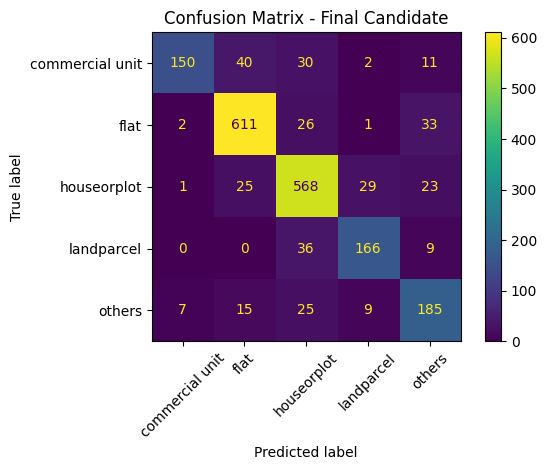

In [179]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_val,
    domain_predictions,
    labels=sorted(y_train.unique())
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(y_train.unique())
)

disp.plot(
    xticks_rotation=45
)

plt.title("Confusion Matrix - Final Candidate")
plt.tight_layout()
plt.show()

Example

In [180]:
X_full = df["clean_address"]
y_full = df["categories"]

In [181]:
word_vectorizer_final = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

char_vectorizer_final = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 5),
    min_df=2,
    sublinear_tf=True
)

In [182]:
X_word_full = word_vectorizer_final.fit_transform(
    X_full
)

X_char_full = char_vectorizer_final.fit_transform(
    X_full
)

In [183]:
X_full_combined = hstack([
    X_word_full,
    X_char_full
])

In [189]:
final_model = LinearSVC(
    C=1.0,
    class_weight=None
)

final_model.fit(
    X_full_combined,
    y_full
)

LinearSVC()

In [186]:
import joblib
import os

os.makedirs("best_model", exist_ok=True)

joblib.dump(
    final_model,
    "best_model/model.pkl"
)

joblib.dump(
    word_vectorizer_final,
    "best_model/word_vectorizer.pkl"
)

joblib.dump(
    char_vectorizer_final,
    "best_model/char_vectorizer.pkl"
)

['best_model/char_vectorizer.pkl']

In [187]:
os.listdir("best_model")

['char_vectorizer.pkl', 'model.pkl', 'word_vectorizer.pkl']

In [188]:
import argparse
import joblib
import pandas as pd
from scipy.sparse import hstack
import unicodedata
import re


def normalize_text(text):
    text = str(text)

    # Unicode normalization
    text = unicodedata.normalize("NFKC", text)

    # Remove invisible format characters
    text = "".join(
        ch for ch in text
        if unicodedata.category(ch) not in {"Cf"}
    )

    # Lowercase
    text = text.lower()

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


def main():

    parser = argparse.ArgumentParser()

    parser.add_argument(
        "--input",
        required=True
    )

    parser.add_argument(
        "--output",
        required=True
    )

    args = parser.parse_args()

    # Load input
    df = pd.read_csv(args.input)

    # Validate columns
    required_columns = {
        "id",
        "property_address"
    }

    missing = required_columns - set(df.columns)

    if missing:
        raise ValueError(
            f"Missing required columns: {missing}"
        )

    # Load artifacts
    model = joblib.load(
        "best_model/model.pkl"
    )

    word_vectorizer = joblib.load(
        "best_model/word_vectorizer.pkl"
    )

    char_vectorizer = joblib.load(
        "best_model/char_vectorizer.pkl"
    )

    # Preprocess
    clean_addresses = df["property_address"].apply(
        normalize_text
    )

    # Transform
    X_word = word_vectorizer.transform(
        clean_addresses
    )

    X_char = char_vectorizer.transform(
        clean_addresses
    )

    X_combined = hstack([
        X_word,
        X_char
    ])

    # Predict
    predictions = model.predict(
        X_combined
    )

    # Required output
    output = pd.DataFrame({
        "id": df["id"],
        "categories": predictions
    })

    output.to_csv(
        args.output,
        index=False
    )


if __name__ == "__main__":
    main()

usage: colab_kernel_launcher.py [-h] --input INPUT --output OUTPUT
colab_kernel_launcher.py: error: the following arguments are required: --input, --output
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/lib/python3.13/argparse.py", line 1965, in _parse_known_args2
    namespace, args = self._parse_known_args(args, namespace, intermixed)
                      ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.13/argparse.py", line 2262, in _parse_known_args
    raise ArgumentError(None, _('the following arguments are required: %s') %
               ', '.join(required_actions))
argparse.ArgumentError: the following arguments are required: --input, --output

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_795/443763950.py", line 112, in <cell line: 0>
    main()
    ~~~~^^
  File "/tmp/ipykernel_795/443763950.py", line 44, in m

TypeError: object of type 'NoneType' has no len()